# Threshold estimation for `resolve_routes`

`resolve_routes` filters graph-DTW route matches by upper/lower bounds on a few quality signals. Picking those bounds by eye is fragile. `suggest_thresholds` estimates them from the data: each metric forms a tight **good cluster** plus a **tail** of wrong/poor matches, and the tool finds the cut between them (a two-population separator when there is a real bad cluster, else a robust outlier fence).

Estimators compared per metric: Tukey **IQR** & **MAD** fences, a high **percentile**, **Otsu**, a **GMM** crossover (EM), a **KDE valley**, **Kneedle**, and an **IsolationForest** cut. Section 4 adds the *multivariate* IsolationForest — flagging matches anomalous across all signals jointly.

This notebook runs on the Sundbyberg OSM↔NVDB data and applies the recommended thresholds vs. the old hand-picked `25 / 45 / 95`.

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))
from network_matching import (DuckDBMapMatcher, suggest_thresholds,
                              isolation_forest_flags, setup_logging)
setup_logging(console=False)

m = DuckDBMapMatcher.from_wkt_csv(
    '../data/osm_edges.csv', '../data/sweden_edges.csv',
    id_a='edge_id', id_b='directed_id', utm_srid=3006, max_distance=30)
rl, rs = m.match_routes(n_jobs=-1)
print(f'matched: {(rs.match_type != "NO_MATCH").sum()}   NO_MATCH: {(rs.match_type == "NO_MATCH").sum()}')

matched: 3344   NO_MATCH: 604


## 1. Estimate thresholds
Runs every estimator per metric (now including `iforest`), prints a report, and saves a 2x2 diagnostic plot.

In [2]:
sugg = suggest_thresholds(rs, report=True, plot_path='../output/threshold_suggestions.png')
sugg['recommended']

      QUALITY THRESHOLD SUGGESTIONS (resolve_routes)
rows total             : 3948   (NO_MATCH excluded: 604)

-- dtw_distance (lower better, n=3344) --
   summary   : p50=2.69  p90=30.14  p95=45.05  p99=84.10  max=382.55
   iqr=20.47  mad=9.71  p97.5=59.72  otsu=23.92
   kde_valley=10.81  gmm=5.69 (sep=1.6)  kneedle=8.12  iforest=7.42
   -> max_match_dist = 7.418   [bimodal (KDE valley (GMM sep=1.6<2.0)): good/bad crossover]

-- max_dtw_distance (lower better, n=3344) --
   summary   : p50=5.11  p90=56.93  p95=84.25  p99=160.53  max=820.06
   iqr=42.71  mad=16.25  p97.5=114.94  otsu=49.96
   kde_valley=24.85  gmm=10.34 (sep=1.6)  kneedle=13.88  iforest=12.87
   -> max_max_dist = 12.874   [bimodal (KDE valley (GMM sep=1.6<2.0)): good/bad crossover]

-- bearing_diff (lower better, n=3344) --
   summary   : p50=1.49  p90=59.94  p95=74.74  p99=88.32  max=179.31
   iqr=28.85  mad=7.57  p97.5=82.46  otsu=32.81
   kde_valley=14.93  gmm=4.26 (sep=1.9)  kneedle=7.11  iforest=4.73
   -> max_bea

{'max_match_dist': 7.418,
 'max_max_dist': 12.874,
 'max_bearing_diff': 4.734,
 'min_overlap_pct': 97.0}

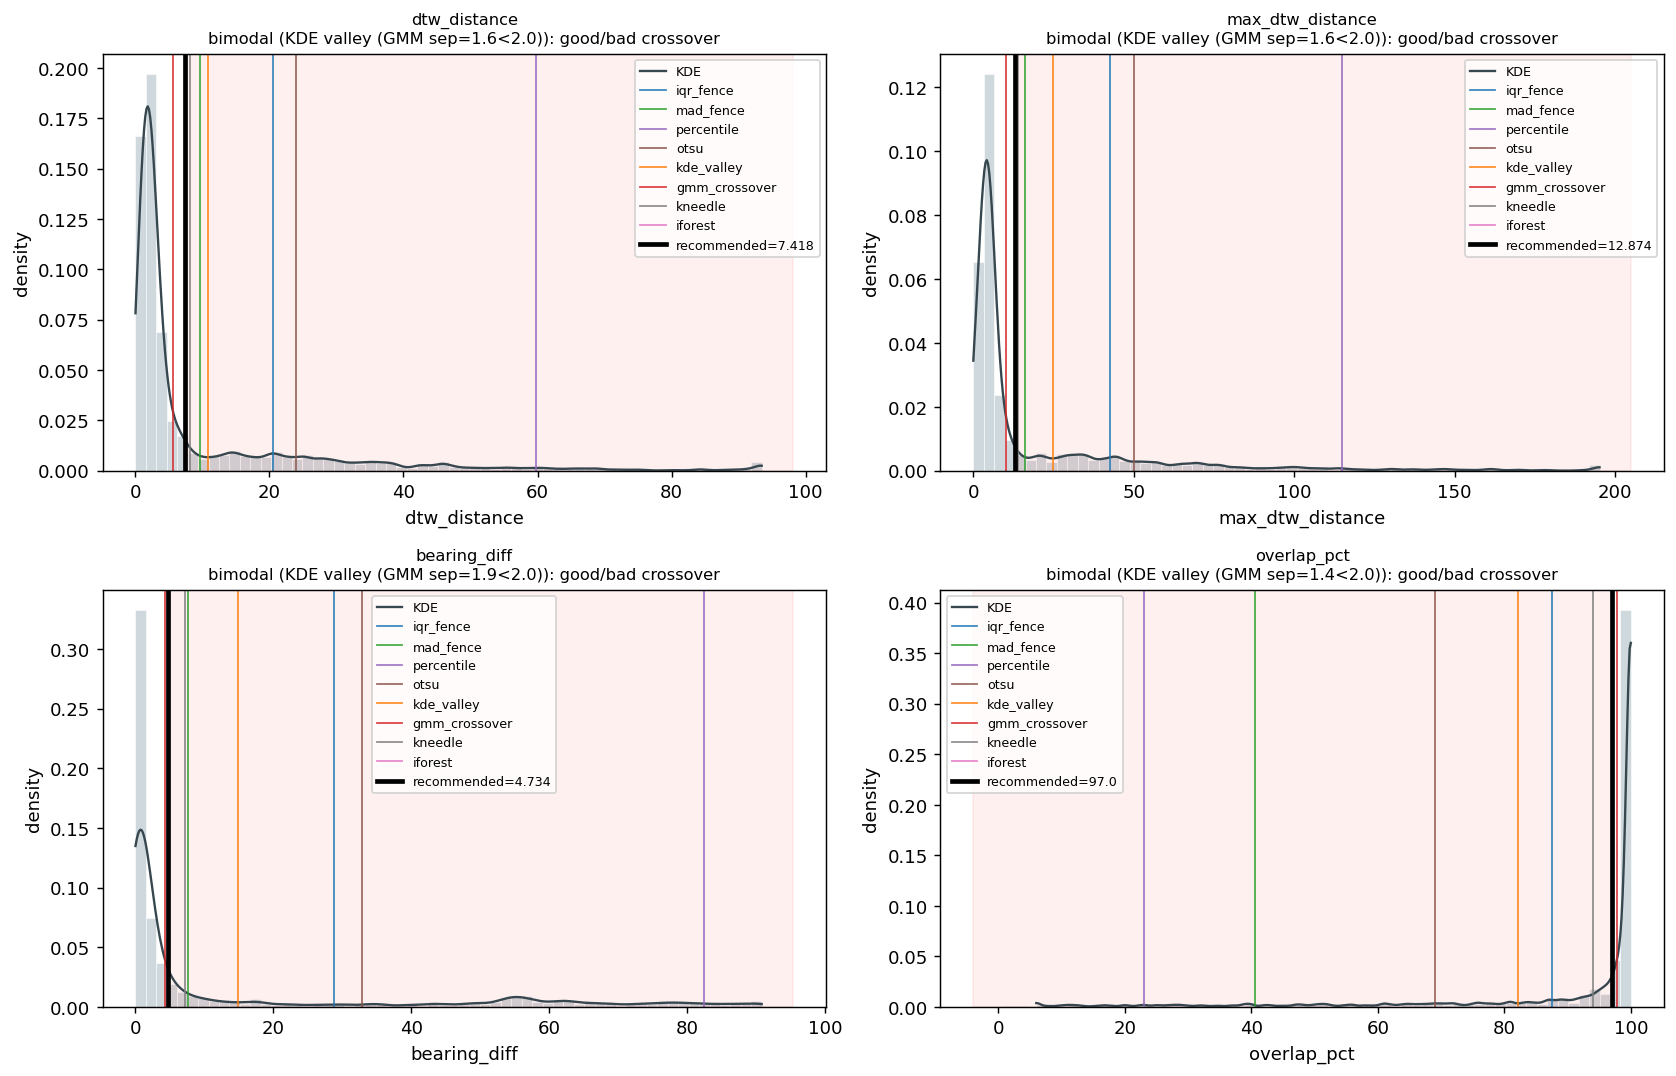

In [3]:
from IPython.display import Image
Image('../output/threshold_suggestions.png')

## 2. Compare the per-metric estimators
Each method's suggested cut, side by side. IsolationForest (`iforest`) is a tree-based outlier cut; note it can dip into the good cluster's upper tail in 1-D (its strength is multivariate, section 4).

In [4]:
import pandas as pd
rows = []
for met, sub in sugg['metrics'].items():
    r = {'metric': met, **sub['methods'], 'recommended': sub['recommended']}
    rows.append(r)
pd.DataFrame(rows).set_index('metric')

,iqr_fence,mad_fence,percentile,otsu,kde_valley,gmm_crossover,kneedle,iforest,recommended
metric,,,,,,,,,
dtw_distance,20.473,9.705,59.715,23.923,10.807,5.688,8.119,7.418,7.418
max_dtw_distance,42.711,16.253,114.935,49.956,24.853,10.344,13.884,12.874,12.874
bearing_diff,28.847,7.567,82.463,32.809,14.926,4.265,7.114,4.734,4.734
overlap_pct,87.500,40.657,23.000,68.973,82.157,97.793,94.000,97.000,97.000


## 3. Apply the recommended cut vs. the old hand-picked one
`sugg['recommended']` plugs straight into `resolve_routes` (it now also filters max distance via `max_max_dist`).

In [5]:
rs_auto, rl_auto = m.resolve_routes(rs, rl, **sugg['recommended'])
rs_hand, rl_hand = m.resolve_routes(rs, rl, max_match_dist=25, max_bearing_diff=45, min_overlap_pct=95)

def summarize(name, r):
    keep = r[r.match_type != 'NO_MATCH']
    cov = keep.overlap_pct.astype('float')
    return {'set': name, 'matched': len(keep), 'NO_MATCH': int((r.match_type=='NO_MATCH').sum()),
            'avg_dist_median': round(keep.dtw_distance.median(), 2),
            'cover_median': round(cov.median(), 1)}

pd.DataFrame([summarize('raw', rs), summarize('auto (suggested)', rs_auto),
              summarize('hand 25/45/95', rs_hand)]).set_index('set')

,matched,NO_MATCH,avg_dist_median,cover_median
set,,,,
raw,3344,604,2.69,100.0
auto (suggested),1919,2029,1.85,100.0
hand 25/45/95,2314,1634,2.04,100.0


## 4. IsolationForest — multivariate joint outliers
The per-metric `iforest` above cuts each axis alone. IsolationForest's real strength is **multivariate**: `isolation_forest_flags` fits one forest on all quality signals jointly (z-scored; `overlap_pct` flipped to a deficit) and flags matches that are anomalous *in combination* — a route can look acceptable on each axis yet sit in a sparse region of the joint space.

In [6]:
flagged = isolation_forest_flags(rs, report=True)
flagged['if_outlier'].sum()

   MULTIVARIATE OUTLIERS (IsolationForest, joint)
matched rows scored : 3344   features: ['dtw_distance', 'max_dtw_distance', 'bearing_diff', 'overlap_pct']
flagged as outliers : 850  (25.4%)
worst (lowest if_score) examples:
   src 3535: dtw_distance=359.58728341378065  max_dtw_distance=733.6919087094419  bearing_diff=3.6487405029878346  overlap_pct=3  score=-0.309
   src 222: dtw_distance=263.55228625246764  max_dtw_distance=580.0208411357304  bearing_diff=30.721816885496025  overlap_pct=3  score=-0.296
   src 3389: dtw_distance=303.0999725321169  max_dtw_distance=550.6334302207008  bearing_diff=60.11278003610249  overlap_pct=1  score=-0.292
   src 598: dtw_distance=176.06871226069552  max_dtw_distance=354.3291675402033  bearing_diff=22.346007891771876  overlap_pct=2  score=-0.283
   src 3316: dtw_distance=166.27312655665105  max_dtw_distance=390.33123007272445  bearing_diff=30.89277246452224  overlap_pct=6  score=-0.275


np.int64(850)

### How does the multivariate flag compare to the per-metric thresholds?
Cross-tabulate: rejected-by-thresholds vs flagged-by-IsolationForest. They agree on the obvious bad matches and disagree on the borderline ones (each catches cases the other misses).

In [7]:
matched = rs.match_type != 'NO_MATCH'
rejected_by_thresh = matched & (rs_auto.match_type == 'NO_MATCH')
flagged_by_if = flagged['if_outlier']
ct = pd.crosstab(rejected_by_thresh[matched].rename('threshold_rejected'),
                 flagged_by_if[matched].rename('iforest_outlier'))
print(ct)
print('\nthreshold-rejected:', int(rejected_by_thresh.sum()),
      ' iforest-flagged:', int(flagged_by_if.sum()),
      ' both:', int((rejected_by_thresh & flagged_by_if).sum()))

iforest_outlier     False  True 
threshold_rejected              
False                1919      0
True                  575    850

threshold-rejected: 1425  iforest-flagged: 850  both: 850


**Takeaways.** Per-metric `suggest_thresholds` gives interpretable, directly-applicable `resolve_routes` cuts (data-driven starting points — widen if you over-reject, tighten if wrong matches survive). The multivariate IsolationForest is a complementary review tool: it surfaces jointly-weird matches for inspection that no single-axis cut would catch. Tune either via `sep_min` / `k_iqr` / `k_mad` / `percentile` (thresholds) or `contamination` (IsolationForest).